In [17]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import jieba
import nltk
from nltk.corpus import stopwords
import re

In [18]:
# Load CSVs
df_cn = pd.read_csv('douban_reviews.csv')
df_en = pd.read_csv('imdb_reviews.csv')

# Download English stopwords if needed
nltk.download('stopwords')
eng_stopwords = set(stopwords.words('english'))

#load in Chinese stopwords
zh_stopwords = set(open('chinese_stopwords.txt', encoding='utf-8').read().split())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elimarx/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
df_en

,title,comment,rating
0,Se7en,"So when this movie came out, it was pretty gor...",1
1,Se7en,Horrible movie. Incredibly boring and predicta...,1
2,Se7en,What a boring movie. Idk what the stupid hype ...,1
3,Se7en,"Well Kevin ruined the movie, obviously. I'd lo...",1
4,Se7en,Watched this because it was suggested in a rev...,1
...,...,...,...
7702,Django Unchained,Just for a moment imagine this movie being mad...,4
7703,Django Unchained,Last week I managed to watch Django Unchained ...,4
7704,Django Unchained,Another disappointment from Tarantino. A juven...,4
7705,Django Unchained,One thing that you can always guarantee with a...,4


In [44]:
import pandas as pd
import re

def clean_english_text(text):
    if pd.isna(text):
        return text
    # Remove newline characters
    text = re.sub(r'[\r\n]+', ' ', text)
    # Remove English letters, digits, and standard English punctuation
    # text = re.sub(r'[A-Za-z0-9\s.,;:!?\"\'()\-—_+=@#$%^&*<>/\\|`~[\]{}]', '', text)
    return text

# Apply the function to the review_text column
df_en['clean_text'] = df_en['comment'].apply(clean_english_text)

In [54]:
comments = df_en['clean_text']

In [49]:
comments

0       So when this movie came out, it was pretty gor...
1       Horrible movie. Incredibly boring and predicta...
2       What a boring movie. Idk what the stupid hype ...
3       Well Kevin ruined the movie, obviously. I'd lo...
4       Watched this because it was suggested in a rev...
                              ...                        
7702    Just for a moment imagine this movie being mad...
7703    Last week I managed to watch Django Unchained ...
7704    Another disappointment from Tarantino. A juven...
7705    One thing that you can always guarantee with a...
7706    I should start off by saying that I love Taran...
Name: clean_text, Length: 7707, dtype: object

In [50]:
comments.to_csv('english_reviews_clean.csv', index=False)

In [52]:
df_en

,title,comment,rating,clean_text
0,Se7en,"So when this movie came out, it was pretty gor...",1,"So when this movie came out, it was pretty gor..."
1,Se7en,Horrible movie. Incredibly boring and predicta...,1,Horrible movie. Incredibly boring and predicta...
2,Se7en,What a boring movie. Idk what the stupid hype ...,1,What a boring movie. Idk what the stupid hype ...
3,Se7en,"Well Kevin ruined the movie, obviously. I'd lo...",1,"Well Kevin ruined the movie, obviously. I'd lo..."
4,Se7en,Watched this because it was suggested in a rev...,1,Watched this because it was suggested in a rev...
...,...,...,...,...
7702,Django Unchained,Just for a moment imagine this movie being mad...,4,Just for a moment imagine this movie being mad...
7703,Django Unchained,Last week I managed to watch Django Unchained ...,4,Last week I managed to watch Django Unchained ...
7704,Django Unchained,Another disappointment from Tarantino. A juven...,4,Another disappointment from Tarantino. A juven...
7705,Django Unchained,One thing that you can always guarantee with a...,4,One thing that you can always guarantee with a...


In [22]:
df_en = df_en[~(df_en == "").any(axis=1)]
df_en

,title,review_text,stars,url,noenglish_text
0,Bohemian Rhapsody,一句话，电影就是不及格的！\n内容不尊重事实，各种想当然，而且表述和模仿都太流于表面，幼稚而...,1,https://movie.douban.com/review/10052620/,一句话，电影就是不及格的！内容不尊重事实，各种想当然，而且表述和模仿都太流于表面，幼稚而且肤...
1,Bohemian Rhapsody,一个天才音乐艺人，傲慢无礼，骄狂自大的性格。逃避家庭的叛逆灵魂，却依托了爱好音乐的一群队友。...,1,https://movie.douban.com/review/10076604/,一个天才音乐艺人，傲慢无礼，骄狂自大的性格。逃避家庭的叛逆灵魂，却依托了爱好音乐的一群队友。...
2,Bohemian Rhapsody,在坐的给这片子打五星的，有几个是那个年代出生的？听过皇后乐队现场表演的有几个？一部叙事风格的...,1,https://movie.douban.com/review/9985323/,在坐的给这片子打五星的，有几个是那个年代出生的？听过皇后乐队现场表演的有几个？一部叙事风格的...
4,Bohemian Rhapsody,一个路人的角度，我喜欢听音乐，但也没有深入了解过，这部电影音乐我个人欣赏不来，从影片中我也没...,1,https://movie.douban.com/review/10544688/,一个路人的角度，我喜欢听音乐，但也没有深入了解过，这部电影音乐我个人欣赏不来，从影片中我也没...
5,Bohemian Rhapsody,说句实话，作为电影来说，拍的有点太差了。整个节奏，氛围营造的没有代入感。很多人说是因为对口型...,1,https://movie.douban.com/review/10516274/,说句实话，作为电影来说，拍的有点太差了。整个节奏，氛围营造的没有代入感。很多人说是因为对口型...
...,...,...,...,...,...
2700,Life Is Beautiful,忍受着意大利语的吵闹看完了，冲着前半段男主追女主的情节及军医的谜语给个二星，但是恕我直言的确...,2,https://movie.douban.com/review/8975354/,忍受着意大利语的吵闹看完了，冲着前半段男主追女主的情节及军医的谜语给个二星，但是恕我直言的确...
2701,Life Is Beautiful,从电影主题来看，是要将小人物的乐观和历史灾难做对比，以此更加衬托出人们美好的心灵，同时痛斥战...,2,https://movie.douban.com/review/9282691/,从电影主题来看，是要将小人物的乐观和历史灾难做对比，以此更加衬托出人们美好的心灵，同时痛斥战...
2702,Life Is Beautiful,真相虽然残酷，但是确实生命的必经部分，即使对于一个孩子而已，\n也是如此。\n\n有时候，即...,2,https://movie.douban.com/review/3211968/,真相虽然残酷，但是确实生命的必经部分，即使对于一个孩子而已，也是如此。有时候，即使是善意的欺...
2703,Life Is Beautiful,RT.\n看拍摄我以为是1979年的片子呢……\n演技很差\n道具很假\n至于广泛渲染的煽情...,2,https://movie.douban.com/review/1407755/,看拍摄我以为是年的片子呢……演技很差道具很假至于广泛渲染的煽情也被约舒亚糟糕的演技弄得没煽出来


In [4]:
# Chinese preprocessing
def clean_chinese(text):
    text = re.sub(r"[^\u4e00-\u9fa5]", "", str(text))  # Keep only Chinese
    words = jieba.lcut(text)
    words = [word for word in words if word not in zh_stopwords]
    return ' '.join(words)

# English preprocessing
def clean_english(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w not in eng_stopwords]
    return ' '.join(words)

# Apply preprocessing
df_cn['clean_comment'] = df_cn['review_text'].apply(clean_chinese)
df_en['clean_comment'] = df_en['comment'].apply(clean_english)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/m_/hhg0dx_j62qbf4m6rdt4_3qc0000gn/T/jieba.cache
Loading model cost 0.277 seconds.
Prefix dict has been built successfully.


In [6]:
comments = df_cn["clean_comment"].dropna().tolist()

In [ ]:
comments1 = df_en["clean_comment"].dropna().tolist()

In [7]:
from sentence_transformers import SentenceTransformer

# Use a multilingual model or a specific Chinese one
model = SentenceTransformer("shibing624/text2vec-base-chinese")
# For more accurate results with Chinese: "shibing624/text2vec-base-chinese"

embeddings = model.encode(comments, show_progress_bar=True)

/Users/elimarx/miniconda3/lib/python3.13/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
/Users/elimarx/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
/Users/elimarx/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._

In [10]:
embedding = embeddings

In [11]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 6  # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embedding)

df_cn['cluster'] = labels

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [17]:
!pip install BCEmbedding

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached BCEmbedding-0.1.5-py3-none-any.whl.metadata (32 kB)
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached tokenizers-0.15.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.7 kB)
  Using cached pyarrow-20.0.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (3.3 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
  Using cached sentence_transformers-4.0.2-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.1-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.0-

In [23]:
from BCEmbedding import EmbeddingModel

model = EmbeddingModel("maidalun1020/bce-embedding-base_v1")
embedding = model.encode(comments, lexicon_aware=True)

05/25/2025 02:00:58 - [INFO] -BCEmbedding.models.EmbeddingModel->>>    Loading from `maidalun1020/bce-embedding-base_v1`.
05/25/2025 02:00:58 - [INFO] -BCEmbedding.models.EmbeddingModel->>>    Execute device: cpu;	 gpu num: 0;	 use fp16: False;	 embedding pooling type: cls;	 trust remote code: False
Extract embeddings:   0%|          | 0/11 [00:48<?, ?it/s]


KeyboardInterrupt: 

In [12]:
#print some random comments from each cluster
for cluster_num in sorted(df_cn['cluster'].unique()):
    print(f"\nCluster {cluster_num}:")
    sample_comments = df_cn[df_cn['cluster'] == cluster_num]['clean_comment'].sample(4, random_state=42)
    for comment in sample_comments:
        print(" -", comment)


Cluster 0:
 - 谢邀 刚 完 黑漫威 黑 重度 抑郁症 患者 现 基本 好转 个人 认为 小丑 整个 人物 塑造 故事 逻辑 失败 人物 动机 不合理 角色 转变 不合理 创作 团队 精神疾病 毫无 了解 打着 精神疾病 幌子 胡编乱造 强行 恶人 塑造成 英雄 手枪 这条线 细节 阐述 逻辑 不自洽 第一次 同事 兰道 枪 交给 亚瑟 隐约 看到 袋子 里 至少 有发 子弹 非常 熟悉 枪械 应该 已经 认出 枪 属于 半吊子 尚未 识别 出是 枪 第二次 亚瑟 家里 玩枪 此幕 没有 表现 亚瑟 装填 弹药 细节 特写镜头 看到 桌上 大约 发 子弹 全景 镜头 中子弹 摆放 位置 特写镜头 位置 一致 细节 不究 亚瑟 跳舞 误触 走火 掉 一发 子弹 第三次 看到 是从 亚瑟 裤腿 内掉 侧边 口袋 掉 推测 亚瑟 枪 插 腰带 腹部 之间 从枪 外形 大致 判断 净重 发弹 筒 属于 尺寸 枪械 净重 克 净重 克 三星 净重 约克 英寸 机械 硬盘 大约 也就是说 一把 手枪 重量 相当于 部 最新款 大屏幕 手机 重量 加 一块儿 想象 一下 随身带 部 最新款 旗舰 台 机器 绑 一起 揣 同一个 口袋 里 舒服 感觉 不到 可能 重量 足够 没系 腰带 裤子 扯掉 下去 绝对 不会 忽略 重 玩意儿 孤儿院 一幕 只能 两种 解释 亚瑟 故意 带进去 结合 剧情 毫无 理由 亚瑟 犯病 忘 身上 带枪 这是 目前 唯一 合理 解释 导演 编剧 强行 塑造 戏剧 冲突 忽略 逻辑 合理性 可能性 结合 全片 剧情 最大 第四次 地铁 杀掉 金融 男 第发 子弹 寸头 金融 男 正中 右额 第发 子弹 白衣 金融 男 心脏 左腹 一发 第发弹 卷发 金融 男 全部打 背部 地铁 杀人 这幕 亚瑟 没有 装弹 细节 发弹 筒 出发 子弹 明显 剧组 工作失误 第五次 剧情 暗示 托马斯 韦恩 为富不仁 地板 报纸 直接 标题 杀富 一场 新 运动 第六次 注意 两个 细节 亚瑟 沙发 拔枪 时枪 挂 衣服 没 拔出来 第二次 亚瑟 开枪 撞针 明确 击发 弹筒 没有 子弹 结合 剧情 亚瑟 应该 已经 清空 弹筒 第七次 亚瑟 枪 警探 枪 注意 旁边 面具 人用 手 直接 抓住 警探 持枪 手 已经 属于 严重 袭警 行为 好莱坞 电影 

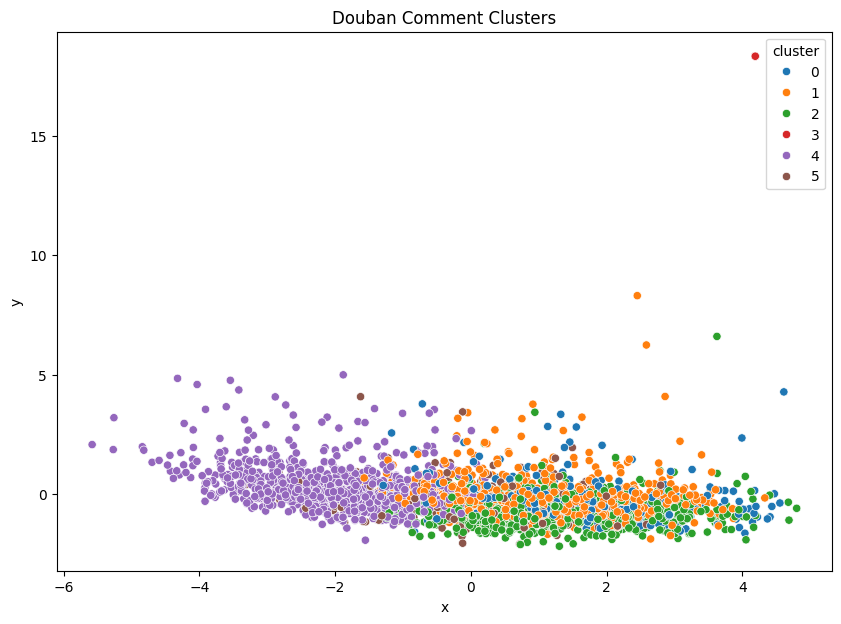

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

df_cn['x'] = reduced[:, 0]
df_cn['y'] = reduced[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_cn, x='x', y='y', hue='cluster', palette='tab10')
plt.title("Douban Comment Clusters")
plt.show()

In [14]:
from keybert import KeyBERT

kw_model = KeyBERT(model)
for i in range(num_clusters):
    cluster_comments = df_cn[df_cn['cluster'] == i]['clean_comment'].tolist()
    joined = " ".join(cluster_comments)
    keywords = kw_model.extract_keywords(joined, top_n=5)
    print(f"Cluster {i} keywords:", keywords)

Cluster 0 keywords: [('一塌糊涂', 0.6227), ('显露出', 0.6177), ('一个个', 0.6173), ('真是', 0.6164), ('有过', 0.614)]
Cluster 1 keywords: [('苟延残喘', 0.5964), ('般地', 0.5957), ('男二之口', 0.5837), ('人罗伊之口', 0.5813), ('一个个', 0.5804)]
Cluster 2 keywords: [('呆演', 0.6312), ('一个个', 0.6201), ('扯进', 0.6193), ('技傻白', 0.6193), ('第一个', 0.6177)]
Cluster 3 keywords: []
Cluster 4 keywords: [('戏大有', 0.6411), ('測電影', 0.6118), ('可说是', 0.6103), ('首第一个', 0.6101), ('冠冕堂皇', 0.6098)]
Cluster 5 keywords: [('有目共睹', 0.6481), ('精彩绝伦', 0.6438), ('堪称', 0.6348), ('一大群', 0.6337), ('这一作', 0.6299)]


In [21]:
df_cn['cluster'].value_counts()

cluster
4    915
1    575
2    570
5    327
0    297
3     21
Name: count, dtype: int64